In [1]:
#Use only twice to run the program and comment the code again
#%pip install -r ../requirements.txt

In [2]:
#Personal note, remember to put all import module in here

#tbh, I rather see the imports called inside the code cell of needed, or it just a beginner view to import placement?

In [3]:
import pandas as pd
weather = pd.read_excel("../dataset/openmeteo_makassar_weather.xlsx")

In [4]:
weather.to_csv("../dataset/openmeteo_makassar_weather.csv")

In [5]:
weather.head()

,time,temperature_2m_mean,temperature_2m_max,sunshine_duration,precipitation_sum,apparent_temperature_mean,wind_speed_10m_max,shortwave_radiation_sum,weather_code,temperature_2m_min
0,2010-01-01,26.6,28.0,32535.21,6.9,31.4,12.3,16.71,61,24.8
1,2010-01-02,26.6,28.1,40311.63,2.8,31.5,14.5,19.30,61,25.3
2,2010-01-03,26.4,28.3,35355.65,1.4,31.5,14.3,16.99,53,24.7
3,2010-01-04,25.9,27.0,29237.88,7.5,30.9,10.4,15.13,61,25.1
4,2010-01-05,25.3,27.4,18944.19,30.3,29.9,13.8,11.56,63,24.5


In [6]:
weather.shape

(5844, 10)

In [7]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5844 entries, 0 to 5843
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   time                       5844 non-null   datetime64[ns]
 1   temperature_2m_mean        5844 non-null   float64       
 2   temperature_2m_max         5844 non-null   float64       
 3   sunshine_duration          5844 non-null   float64       
 4   precipitation_sum          5844 non-null   float64       
 5   apparent_temperature_mean  5844 non-null   float64       
 6   wind_speed_10m_max         5844 non-null   float64       
 7   shortwave_radiation_sum    5844 non-null   float64       
 8   weather_code               5844 non-null   int64         
 9   temperature_2m_min         5844 non-null   float64       
dtypes: datetime64[ns](1), float64(8), int64(1)
memory usage: 456.7 KB


In [8]:
weather.isna().sum()

time                         0
temperature_2m_mean          0
temperature_2m_max           0
sunshine_duration            0
precipitation_sum            0
apparent_temperature_mean    0
wind_speed_10m_max           0
shortwave_radiation_sum      0
weather_code                 0
temperature_2m_min           0
dtype: int64

In [9]:
input = weather.drop(['time','temperature_2m_mean'], axis = 1)
output = weather['temperature_2m_mean']

In [10]:
input.head()

,temperature_2m_max,sunshine_duration,precipitation_sum,apparent_temperature_mean,wind_speed_10m_max,shortwave_radiation_sum,weather_code,temperature_2m_min
0,28.0,32535.21,6.9,31.4,12.3,16.71,61,24.8
1,28.1,40311.63,2.8,31.5,14.5,19.30,61,25.3
2,28.3,35355.65,1.4,31.5,14.3,16.99,53,24.7
3,27.0,29237.88,7.5,30.9,10.4,15.13,61,25.1
4,27.4,18944.19,30.3,29.9,13.8,11.56,63,24.5


In [11]:
output.head()

0    26.6
1    26.6
2    26.4
3    25.9
4    25.3
Name: temperature_2m_mean, dtype: float64

## 70:30 Data Split
With the amount of training data being 70% and test data being 30%:

In [12]:
#Split the dataset: 70% for training and 30% for testing
from sklearn.model_selection import train_test_split
X_train,X_test,y_train, y_test = train_test_split(input,output, test_size=0.3,random_state = 1)

In [13]:
#Linear Regression Model Training
from sklearn import linear_model
import time

#Measure training execution time
time_start = time.perf_counter()
reg_linear = linear_model.LinearRegression()
reg_linear.fit(X_train,y_train) #fitting the model to the training data
end_time = time.perf_counter()

#Perform prediction on the test set
predict_linear = reg_linear.predict(X_test)

In [14]:
#Check if the test set and prediction dimensions match
print("Test set shape: ", y_test.shape)
print("Prediction shape: ", predict_linear.shape)

Test set shape:  (1754,)
Prediction shape:  (1754,)


In [15]:
#Linear Regression Evaluation Metrics
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score as r2

mae_reg_linear = mae(y_test, predict_linear)
rmse_reg_linear = rmse(y_test,predict_linear)
mape_reg_linear = mape(y_test,predict_linear)
r2_reg_linear = r2(y_test,predict_linear)
duration_reg_linear = end_time - time_start

print('Linear Regression MAE: {}'.format(mae_reg_linear))
print('Linear Regression RMSE: {}'.format(rmse_reg_linear))
print('Linear Regression MAPE: {}'.format(mape_reg_linear))
print('Linear Regression R2 Score: {}'.format(r2_reg_linear))
print('Training Duration: {:.6f} Seconds'.format(duration_reg_linear))



Linear Regression MAE: 0.16363689740106993
Linear Regression RMSE: 0.20890494640910895
Linear Regression MAPE: 0.00612160178443222
Linear Regression R2 Score: 0.9539146686490478
Training Duration: 0.001883 Seconds


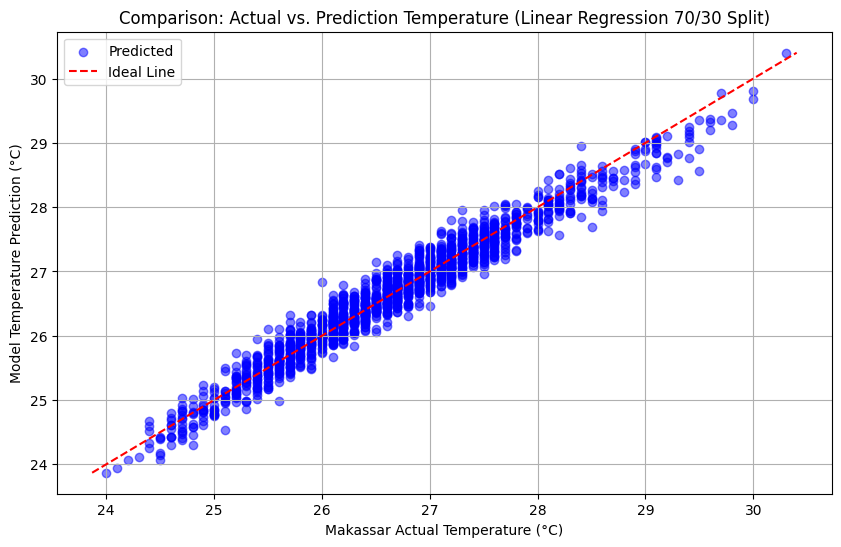

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predict_linear, alpha=0.5, color='blue', label='Predicted')
min_val = min(y_test.min(), predict_linear.min())
max_val = max(y_test.max(), predict_linear.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal Line')
plt.title('Comparison: Actual vs. Prediction Temperature (Linear Regression 70/30 Split)')
plt.xlabel('Makassar Actual Temperature (°C)')
plt.ylabel('Model Temperature Prediction (°C)')
plt.legend()
plt.grid(True)

plt.show()

In [17]:
#Gradient Boosting Model Training
from sklearn.ensemble import GradientBoostingRegressor
import time

#Measure training execution time
time_start = time.perf_counter()
reg_gra_bost = GradientBoostingRegressor()
reg_gra_bost.fit(X_train,y_train) #fitting the model to the training data
end_time = time.perf_counter()

#Perform prediction on the test set
predict_gra_bost = reg_gra_bost.predict(X_test)

In [18]:
#Gradient Boosting Evaluation Metrics
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score as r2

mae_gra_bost = mae(y_test, predict_gra_bost)
rmse_gra_bost = rmse(y_test,predict_gra_bost)
mape_gra_bost = mape(y_test,predict_gra_bost)
r2_gra_bost = r2(y_test,predict_gra_bost)
duration_gra_bost = end_time - time_start

print('Gradient Boosting Regression MAE : {}'.format(mae_gra_bost))
print('Gradient Boosting Regression RMSE: {}'.format(rmse_gra_bost))
print('Gradient Boosting Regression MAPE: {}'.format(mape_gra_bost))
print('Gradient Boosting Regression R2: {}'.format(r2_gra_bost))
print('Training Duration: {:.6f} Seconds'.format(duration_gra_bost))


Gradient Boosting Regression MAE : 0.13674562893896014
Gradient Boosting Regression RMSE: 0.17736570971941465
Gradient Boosting Regression MAPE: 0.005107931933593551
Gradient Boosting Regression R2: 0.9667796204534111
Training Duration: 0.426027 Seconds


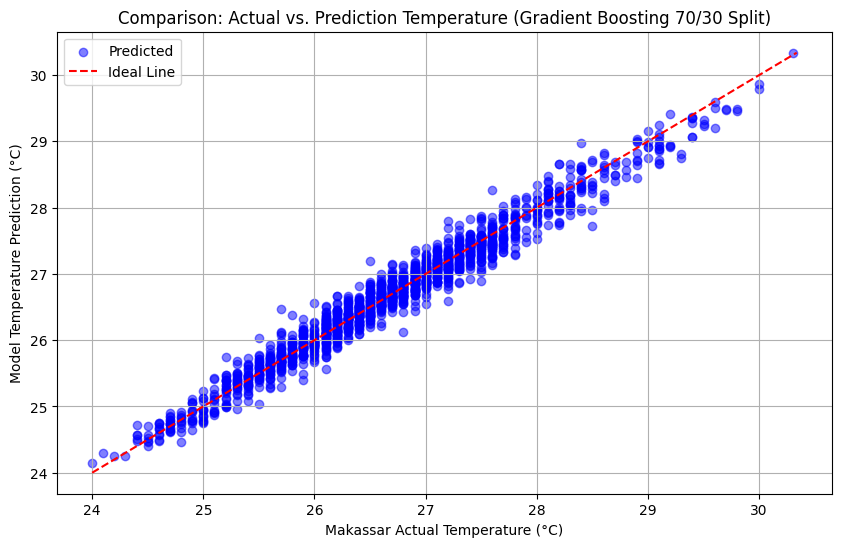

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predict_gra_bost, alpha=0.5, color='blue', label='Predicted')
min_val = min(y_test.min(), predict_gra_bost.min())
max_val = max(y_test.max(), predict_gra_bost.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal Line')
plt.title('Comparison: Actual vs. Prediction Temperature (Gradient Boosting 70/30 Split)')
plt.xlabel('Makassar Actual Temperature (°C)')
plt.ylabel('Model Temperature Prediction (°C)')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
#Adaboost Regression Model Training 
from sklearn.ensemble import AdaBoostRegressor
import time

#Measure training execution time
time_start = time.perf_counter()
reg_adaboost = AdaBoostRegressor()
reg_adaboost.fit(X_train,y_train) #fitting the model to the training data
end_time = time.perf_counter()

#Perform prediction on the test set
predict_adaboost = reg_adaboost.predict(X_test)

In [21]:
#Adaboost Regression Evaluation Metrics
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score as r2

mae_adaboost = mae(y_test, predict_adaboost)
rmse_adaboost = rmse(y_test,predict_adaboost)
mape_adaboost = mape(y_test,predict_adaboost)
r2_adaboost = r2(y_test,predict_adaboost)
duration_adaboost = end_time - time_start

print('AdaBoost Regression MAE Model Regresi: {}'.format(mae_adaboost))
print('AdaBoost Regression RMSE Model Regresi: {}'.format(rmse_adaboost))
print('AdaBoost Regression MAPE Model Regresi: {}'.format(mape_adaboost))
print('AdaBoost Regression R2 Model Regresi: {}'.format(r2_adaboost))
print('Training Duration: {:.6f} Seconds'.format(duration_adaboost))

AdaBoost Regression MAE Model Regresi: 0.20889822065341004
AdaBoost Regression RMSE Model Regresi: 0.26106173529700516
AdaBoost Regression MAPE Model Regresi: 0.0078483251347531
AdaBoost Regression R2 Model Regresi: 0.9280299658336573
Training Duration: 0.202054 Seconds


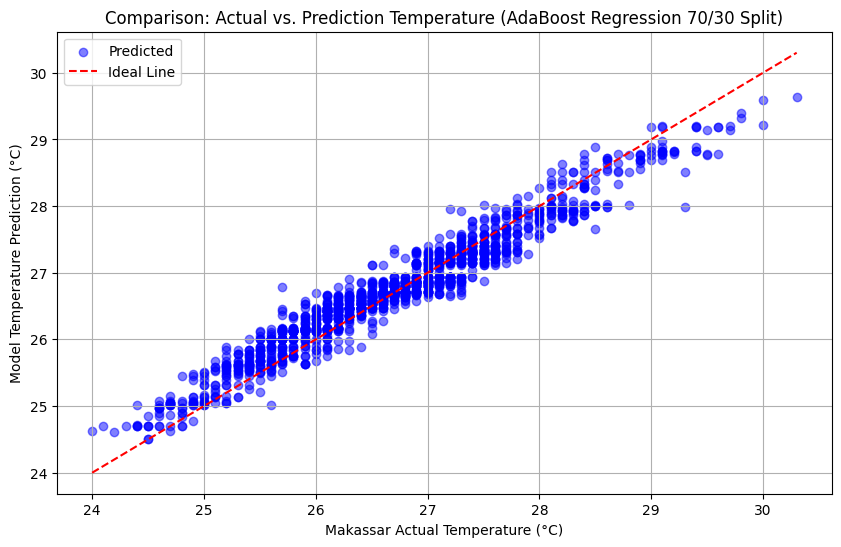

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predict_adaboost, alpha=0.5, color='blue', label='Predicted')
min_val = min(y_test.min(), predict_adaboost.min())
max_val = max(y_test.max(), predict_adaboost.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal Line')
plt.title('Comparison: Actual vs. Prediction Temperature (AdaBoost Regression 70/30 Split)')
plt.xlabel('Makassar Actual Temperature (°C)')
plt.ylabel('Model Temperature Prediction (°C)')
plt.legend()
plt.grid(True)

plt.show()

In [23]:
#XGBoost Regression Model Training
from xgboost import XGBRegressor
import time

#Measure training execution time
time_start = time.perf_counter()
reg_xgboost = XGBRegressor()
reg_xgboost.fit(X_train,y_train) #fitting the model to the training data
end_time = time.perf_counter()

#Perform prediction on the test set
predict_xgboost = reg_xgboost.predict(X_test)

In [24]:
#XGBoost Regression Evaluation Metrics
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score as r2

mae_xgboost = mae(y_test, predict_xgboost)
rmse_xgboost = rmse(y_test,predict_xgboost)
mape_xgboost = mape(y_test,predict_xgboost)
r2_xgboost = r2(y_test,predict_xgboost)
duration_xgboost = end_time - time_start

print('XGboost Regression MAE: {}'.format(mae_xgboost))
print('XGboost Regression RMSE: {}'.format(rmse_xgboost))
print('XGboost Regression MAPE: {}'.format(mape_xgboost))
print('XGboost Regression R2: {}'.format(r2_xgboost))
print('Training Duration: {:.6f} Seconds'.format(duration_xgboost))

XGboost Regression MAE: 0.1420802796036515
XGboost Regression RMSE: 0.18499235065677616
XGboost Regression MAPE: 0.005304335429312063
XGboost Regression R2: 0.9638612763766883
Training Duration: 0.138219 Seconds


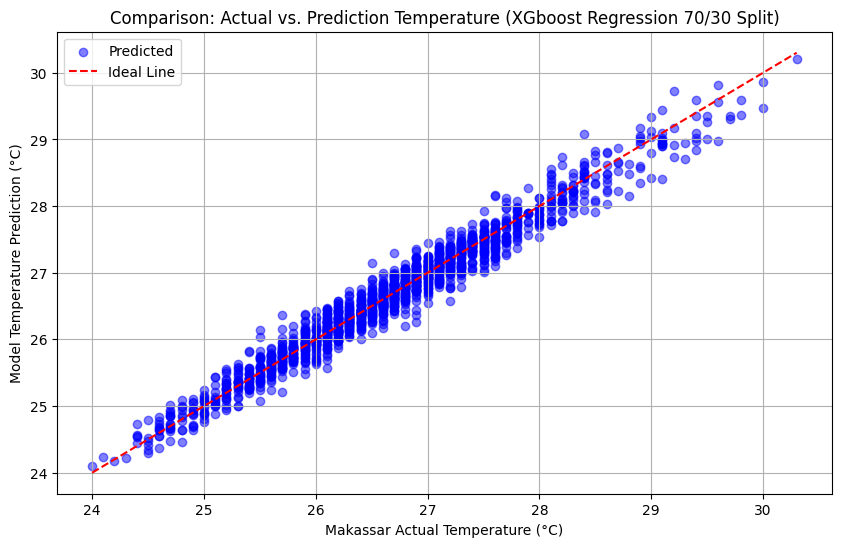

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predict_xgboost, alpha=0.5, color='blue', label='Predicted')
min_val = min(y_test.min(), predict_xgboost.min())
max_val = max(y_test.max(), predict_xgboost.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal Line')
plt.title('Comparison: Actual vs. Prediction Temperature (XGboost Regression 70/30 Split)')
plt.xlabel('Makassar Actual Temperature (°C)')
plt.ylabel('Model Temperature Prediction (°C)')
plt.legend()
plt.grid(True)

plt.show()

In [26]:
#CatBoost Regression Model Training
from catboost import CatBoostRegressor
import time

time_start = time.perf_counter()
reg_catboost = CatBoostRegressor()
reg_catboost.fit(X_train,y_train)
end_time = time.perf_counter()

predict_catboost = reg_catboost.predict(X_test)

Learning rate set to 0.051148
0:	learn: 0.9543593	total: 54.2ms	remaining: 54.2s
1:	learn: 0.9149988	total: 55.5ms	remaining: 27.7s
2:	learn: 0.8776142	total: 56.6ms	remaining: 18.8s
3:	learn: 0.8411880	total: 57.7ms	remaining: 14.4s
4:	learn: 0.8080948	total: 58.8ms	remaining: 11.7s
5:	learn: 0.7765701	total: 59.8ms	remaining: 9.91s
6:	learn: 0.7462756	total: 60.9ms	remaining: 8.64s
7:	learn: 0.7177977	total: 62.1ms	remaining: 7.71s
8:	learn: 0.6906841	total: 63.2ms	remaining: 6.96s
9:	learn: 0.6641966	total: 64.2ms	remaining: 6.36s
10:	learn: 0.6384664	total: 65.3ms	remaining: 5.87s
11:	learn: 0.6143182	total: 66.4ms	remaining: 5.47s
12:	learn: 0.5930682	total: 67.5ms	remaining: 5.13s
13:	learn: 0.5716020	total: 68.6ms	remaining: 4.83s
14:	learn: 0.5508285	total: 69.6ms	remaining: 4.57s
15:	learn: 0.5328999	total: 70.7ms	remaining: 4.35s
16:	learn: 0.5142359	total: 71.8ms	remaining: 4.15s
17:	learn: 0.4960298	total: 72.9ms	remaining: 3.98s
18:	learn: 0.4795516	total: 74ms	remaining: 

In [27]:
#Catboost Regression Evaluation Metrics
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score as r2

mae_catboost = mae(y_test, predict_catboost)
rmse_catboost = rmse(y_test,predict_catboost)
mape_catboost = mape(y_test,predict_catboost)
r2_catboost = r2(y_test,predict_catboost)
duration_catboost = end_time - time_start

print('CatBoost Regression MAE: {}'.format(mae_catboost))
print('CatBoost Regression RMSE: {}'.format(rmse_catboost))
print('CatBoost Regression MAPE: {}'.format(mape_catboost))
print('CatBoost Regression R2: {}'.format(r2_catboost))
print('Training Duration: {:.6f} Seconds'.format(duration_catboost))

CatBoost Regression MAE: 0.1274113972066318
CatBoost Regression RMSE: 0.16544437167220843
CatBoost Regression MAPE: 0.004755267698888113
CatBoost Regression R2: 0.9710952470044029
Training Duration: 1.278199 Seconds


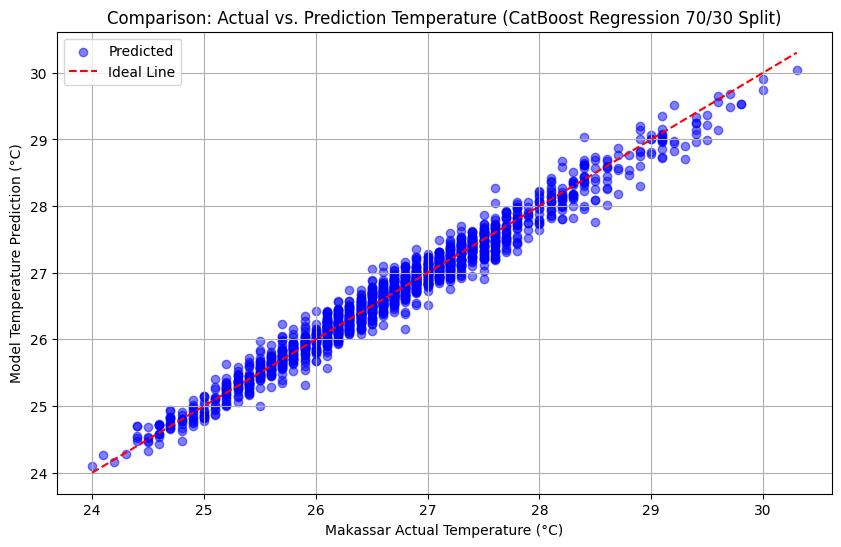

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predict_catboost, alpha=0.5, color='blue', label='Predicted')
min_val = min(y_test.min(), predict_catboost.min())
max_val = max(y_test.max(), predict_catboost.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal Line')
plt.title('Comparison: Actual vs. Prediction Temperature (CatBoost Regression 70/30 Split)')
plt.xlabel('Makassar Actual Temperature (°C)')
plt.ylabel('Model Temperature Prediction (°C)')
plt.legend()
plt.grid(True)

plt.show()

In [29]:
#Light GBM Regression Model Training
from lightgbm import LGBMRegressor
import time

#Measure training execution time
time_start = time.perf_counter()
reg_lightgbm = LGBMRegressor()
reg_lightgbm.fit(X_train,y_train) #fitting the model to the training data
end_time = time.perf_counter()

#Perform prediction on the test set
predict_lightgbm = reg_lightgbm.predict(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000210 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1214
[LightGBM] [Info] Number of data points in the train set: 4090, number of used features: 8
[LightGBM] [Info] Start training from score 26.667702


In [30]:
#LightGBM Regression Evaluation Metrics
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score as r2

mae_lightgbm = mae(y_test, predict_lightgbm)
rmse_lightgbm = rmse(y_test,predict_lightgbm)
mape_lightgbm = mape(y_test,predict_lightgbm)
r2_lightgbm = r2(y_test,predict_lightgbm)
duration_lightgbm = end_time - time_start

print('LightGBM Regression MAE: {}'.format(mae_lightgbm))
print('LightGBM Regression RMSE: {}'.format(rmse_lightgbm))
print('LightGBM Regression MAPE: {}'.format(mape_lightgbm))
print('LightGBM Regression R2: {}'.format(r2_lightgbm))
print('Training Duration: {:.6f} Seconds'.format(duration_lightgbm))

LightGBM Regression MAE: 0.13268342897455698
LightGBM Regression RMSE: 0.1735490110484196
LightGBM Regression MAPE: 0.004948827576772331
LightGBM Regression R2: 0.9681939633992415
Training Duration: 1.291117 Seconds


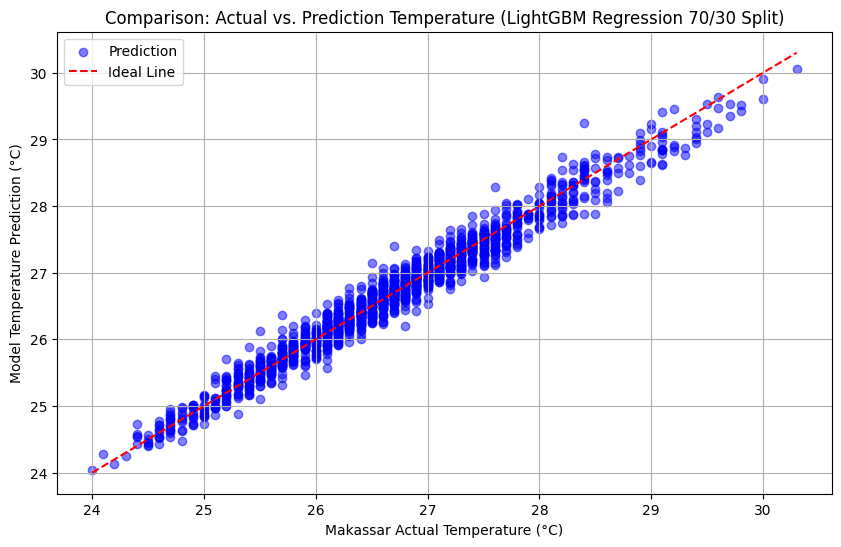

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predict_lightgbm, alpha=0.5, color='blue', label='Prediction')
min_val = min(y_test.min(), predict_lightgbm.min())
max_val = max(y_test.max(), predict_lightgbm.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal Line')
plt.title('Comparison: Actual vs. Prediction Temperature (LightGBM Regression 70/30 Split)')
plt.xlabel('Makassar Actual Temperature (°C)')
plt.ylabel('Model Temperature Prediction (°C)')
plt.legend()
plt.grid(True)

plt.show()

In [32]:
#SVR Linear Regression Model Training
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
import time

time_start = time.perf_counter()
reg_svl_linear = make_pipeline(StandardScaler(), SVR(kernel='linear',C=1.0, epsilon=0.2))
reg_svl_linear.fit(X_train,y_train) #fitting the model to the training data
end_time = time.perf_counter()

#Perform prediction on the test set
predict_svl_linear = reg_svl_linear.predict(X_test)

In [33]:
#Linear SVR Evaluation Metrics
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score as r2

mae_svl_linear = mae(y_test, predict_svl_linear)
rmse_svl_linear = rmse(y_test,predict_svl_linear)
mape_svl_linear = mape(y_test,predict_svl_linear)
r2_svl_linear = r2(y_test,predict_svl_linear)
duration_svl_linear = end_time - time_start

print('Linear SVR MAE: {}'.format(mae_svl_linear))
print('Linear SVR RMSE: {}'.format(rmse_svl_linear))
print('Linear SVR MAPE: {}'.format(mape_svl_linear))
print('Linear SVR R2: {}'.format(r2_svl_linear))
print('Training Duration: {:.6f} Seconds'.format(duration_svl_linear))

Linear SVR MAE: 0.16372487217791037
Linear SVR RMSE: 0.20877112059230155
Linear SVR MAPE: 0.0061238560201599835
Linear SVR R2: 0.9539736948404047
Training Duration: 0.493633 Seconds


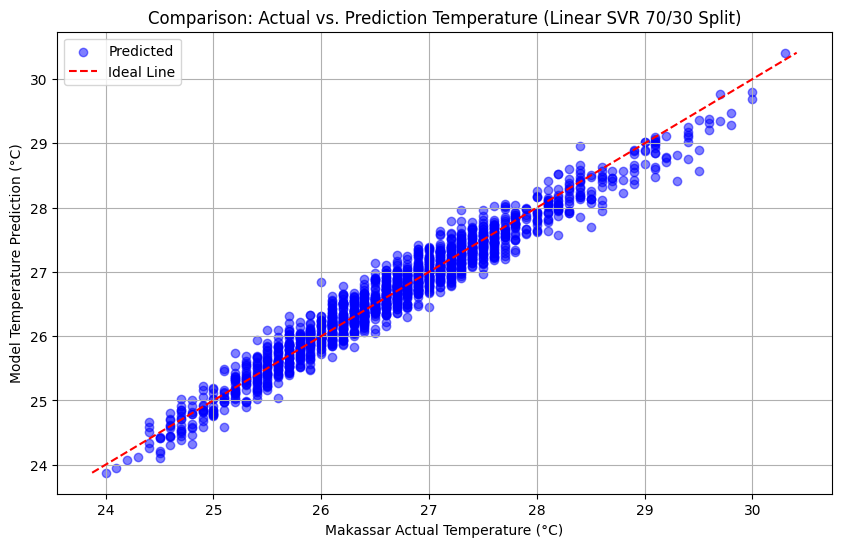

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predict_svl_linear, alpha=0.5, color='blue', label='Predicted')
min_val = min(y_test.min(), predict_svl_linear.min())
max_val = max(y_test.max(), predict_svl_linear.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal Line')
plt.title('Comparison: Actual vs. Prediction Temperature (Linear SVR 70/30 Split)')
plt.xlabel('Makassar Actual Temperature (°C)')
plt.ylabel('Model Temperature Prediction (°C)')
plt.legend()
plt.grid(True)

plt.show()

In [35]:
#SVR RBF Model Training
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
import time

time_start = time.perf_counter()
reg_svl_rbf = make_pipeline(StandardScaler(), SVR(kernel='rbf',C=1.0, epsilon=0.2))
reg_svl_rbf.fit(X_train,y_train)
end_time = time.perf_counter()

predict_svl_rbf = reg_svl_rbf.predict(X_test)

In [36]:
#SVR RBF Evaluation Metrics
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score as r2

mae_svl_rbf = mae(y_test, predict_svl_rbf)
rmse_svl_rbf = rmse(y_test,predict_svl_rbf)
mape_svl_rbf = mape(y_test,predict_svl_rbf)
r2_svl_rbf = r2(y_test,predict_svl_rbf)
duration_svl_rbf = end_time - time_start

print('SVR RBF MAE: {}'.format(mae_svl_rbf))
print('SVR RBF RMSE: {}'.format(rmse_svl_rbf))
print('SVR RBF MAPE: {}'.format(mape_svl_rbf))
print('SVR RBF R2: {}'.format(r2_svl_rbf))
print('Training Duration: {:.6f} Seconds'.format(duration_svl_rbf))

SVR RBF MAE: 0.12891307604376306
SVR RBF RMSE: 0.17036467923587764
SVR RBF MAPE: 0.004811409769587678
SVR RBF R2: 0.9693504298751459
Training Duration: 0.115057 Seconds


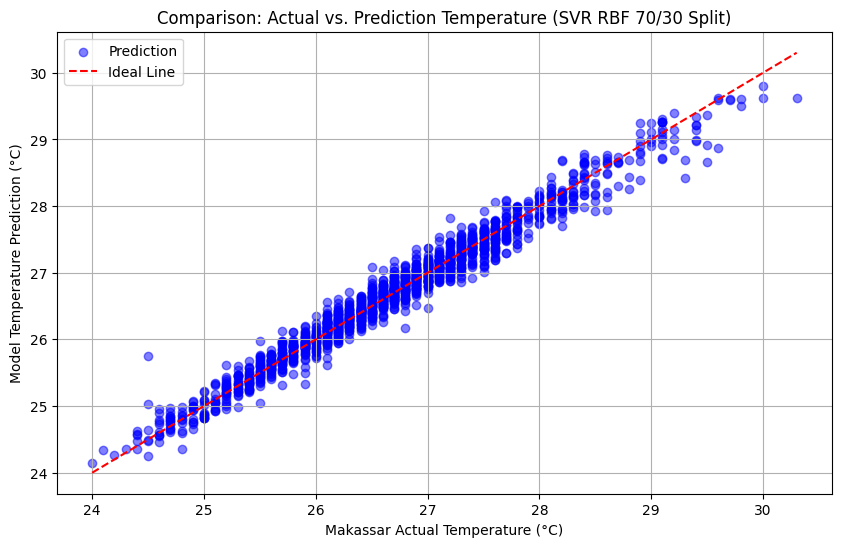

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predict_svl_rbf, alpha=0.5, color='blue', label='Prediction')
min_val = min(y_test.min(), predict_svl_rbf.min())
max_val = max(y_test.max(), predict_svl_rbf.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal Line')
plt.title('Comparison: Actual vs. Prediction Temperature (SVR RBF 70/30 Split)')
plt.xlabel('Makassar Actual Temperature (°C)')
plt.ylabel('Model Temperature Prediction (°C)')
plt.legend()
plt.grid(True)

plt.show()

In [38]:
#SVR Polynomial Model Training
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
import time

time_start = time.perf_counter()
reg_svl_poly = make_pipeline(StandardScaler(), SVR(kernel='poly',C=1.0, epsilon=0.2))
reg_svl_poly.fit(X_train,y_train)
end_time = time.perf_counter()

predict_svl_poly = reg_svl_poly.predict(X_test)

In [39]:
#SVR Polynomial Evaluation Metrics
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score as r2

mae_svl_poly = mae(y_test, predict_svl_poly)
rmse_svl_poly = rmse(y_test,predict_svl_poly)
mape_svl_poly = mape(y_test,predict_svl_poly)
r2_svl_poly = r2(y_test,predict_svl_poly)
duration_svl_poly = end_time - time_start

print('SVR Polynomial MAE: {}'.format(mae_svl_poly))
print('SVR Polynomial RMSE: {}'.format(rmse_svl_poly))
print('SVR Polynomial MAPE: {}'.format(mape_svl_poly))
print('SVR Polynomial R2: {}'.format(r2_svl_poly))
print('Training Duration: {:.6f} Seconds'.format(duration_svl_poly))

SVR Polynomial MAE: 0.30139461517576116
SVR Polynomial RMSE: 0.4043400534783733
SVR Polynomial MAPE: 0.011311818609560093
SVR Polynomial R2: 0.8273530953809399
Training Duration: 0.763766 Seconds


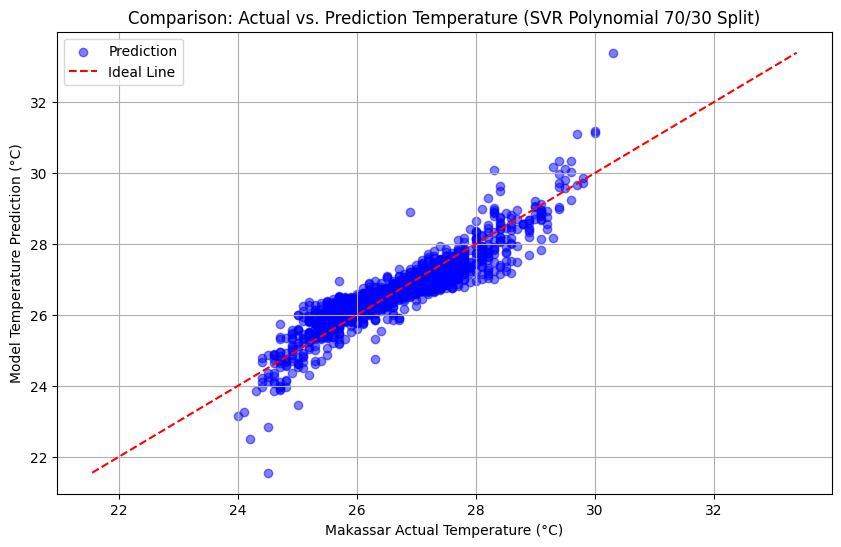

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predict_svl_poly, alpha=0.5, color='blue', label='Prediction')
min_val = min(y_test.min(), predict_svl_poly.min())
max_val = max(y_test.max(), predict_svl_poly.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal Line')
plt.title('Comparison: Actual vs. Prediction Temperature (SVR Polynomial 70/30 Split)')
plt.xlabel('Makassar Actual Temperature (°C)')
plt.ylabel('Model Temperature Prediction (°C)')
plt.legend()
plt.grid(True)

plt.show()

#Section 3
Hasil dengan jumlah data latih adalah 80% dan data uji 20%:

In [41]:
#Bagi data jadi 80 20
from sklearn.model_selection import train_test_split
X_train,X_test,y_train, y_test = train_test_split(input,output, test_size=0.2,random_state = 1)

In [42]:
#Regresi Linear
from sklearn import linear_model
import time

time_start = time.perf_counter()
reg_linear = linear_model.LinearRegression()
reg_linear.fit(X_train,y_train)
end_time = time.perf_counter()

predict_linear = reg_linear.predict(X_test)

In [43]:
print("Jumlah data ujian: ", y_test.shape)
print("Jumlah data tebakan: ", predict_linear.shape)

Jumlah data ujian:  (1169,)
Jumlah data tebakan:  (1169,)


In [44]:
#Hasil Regresi Linear
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score as r2

mae_reg_linear = mae(y_test, predict_linear)
rmse_reg_linear = rmse(y_test,predict_linear)
mape_reg_linear = mape(y_test,predict_linear)
r2_reg_linear = r2(y_test,predict_linear)
duration_reg_linear = end_time - time_start

print('MAE Model Regresi Linear: {}'.format(mae_reg_linear))
print('RMSE Model Regresi Linear: {}'.format(rmse_reg_linear))
print('MAPE Model Regresi Linear: {}'.format(mape_reg_linear))
print('R2 Model Regresi Linear: {}'.format(r2_reg_linear))
print('Waktu Pelatihan: {:.6f} Detik'.format(duration_reg_linear))



MAE Model Regresi Linear: 0.16784578366724767
RMSE Model Regresi Linear: 0.2129307050004794
MAPE Model Regresi Linear: 0.006272326115257438
R2 Model Regresi Linear: 0.9521352704520258
Waktu Pelatihan: 0.001810 Detik


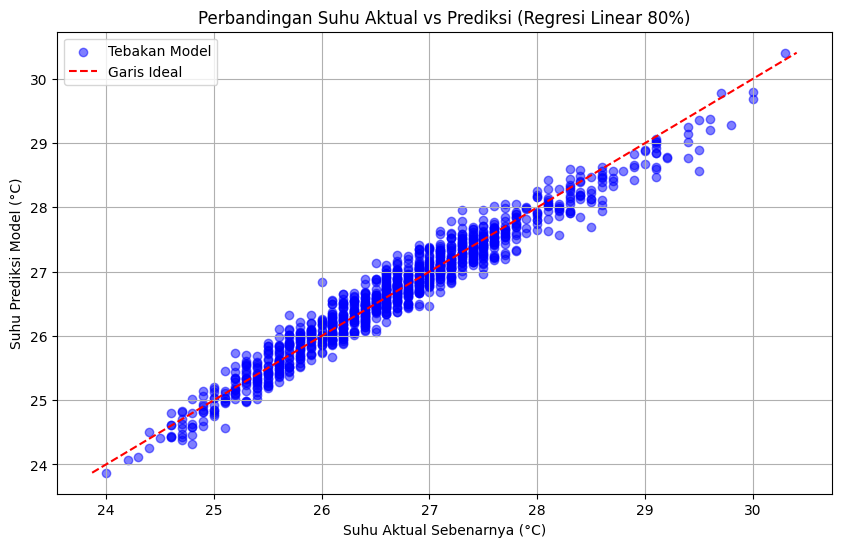

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predict_linear, alpha=0.5, color='blue', label='Tebakan Model')
min_val = min(y_test.min(), predict_linear.min())
max_val = max(y_test.max(), predict_linear.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Garis Ideal')
plt.title('Perbandingan Suhu Aktual vs Prediksi (Regresi Linear 80%)')
plt.xlabel('Suhu Aktual Sebenarnya (°C)')
plt.ylabel('Suhu Prediksi Model (°C)')
plt.legend()
plt.grid(True)

plt.show()

In [46]:
#Regresi Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor
import time

time_start = time.perf_counter()
reg_gra_bost = GradientBoostingRegressor()
reg_gra_bost.fit(X_train,y_train)
end_time = time.perf_counter()

predict_gra_bost = reg_gra_bost.predict(X_test)

In [47]:
#Hasil Regresi Gradient Boosting
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score as r2

mae_gra_bost = mae(y_test, predict_gra_bost)
rmse_gra_bost = rmse(y_test,predict_gra_bost)
mape_gra_bost = mape(y_test,predict_gra_bost)
r2_gra_bost = r2(y_test,predict_gra_bost)
duration_gra_bost = end_time - time_start

print('MAE Model Regresi Gradient Boosting: {}'.format(mae_gra_bost))
print('RMSE Model Regresi Gradient Boosting: {}'.format(rmse_gra_bost))
print('MAPE Model Regresi Gradient Boosting: {}'.format(mape_gra_bost))
print('R2 Model Regresi Gradient Boosting: {}'.format(r2_gra_bost))
print('Waktu Pelatihan: {:.6f} Detik'.format(duration_gra_bost))

MAE Model Regresi Gradient Boosting: 0.13773271040521257
RMSE Model Regresi Gradient Boosting: 0.17719136470640381
MAPE Model Regresi Gradient Boosting: 0.005142473759272114
R2 Model Regresi Gradient Boosting: 0.966854533837077
Waktu Pelatihan: 0.502906 Detik


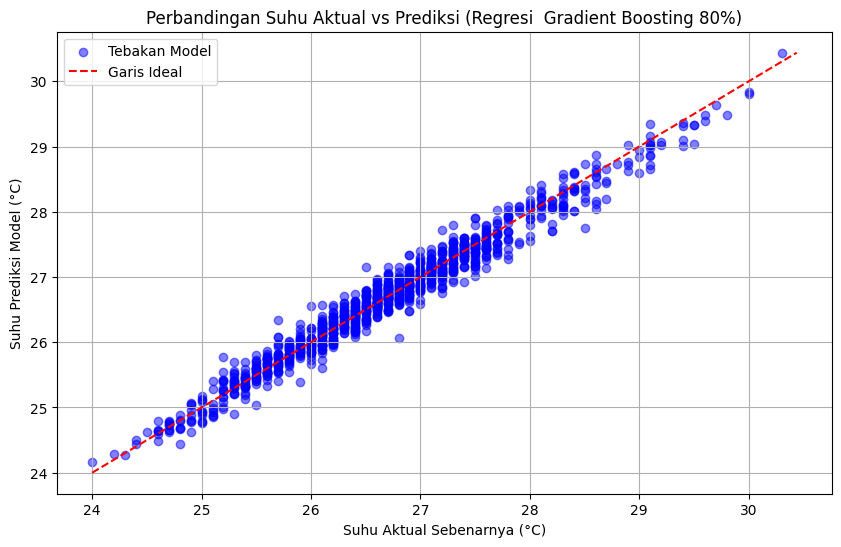

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predict_gra_bost, alpha=0.5, color='blue', label='Tebakan Model')
min_val = min(y_test.min(), predict_gra_bost.min())
max_val = max(y_test.max(), predict_gra_bost.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Garis Ideal')
plt.title('Perbandingan Suhu Aktual vs Prediksi (Regresi  Gradient Boosting 80%)')
plt.xlabel('Suhu Aktual Sebenarnya (°C)')
plt.ylabel('Suhu Prediksi Model (°C)')
plt.legend()
plt.grid(True)

plt.show()

In [49]:
#Regresi Adaboost
from sklearn.ensemble import AdaBoostRegressor
import time

time_start = time.perf_counter()
reg_adaboost = AdaBoostRegressor()
reg_adaboost.fit(X_train,y_train)
end_time = time.perf_counter()

predict_adaboost = reg_adaboost.predict(X_test)

In [50]:
#Hasil Regresi Adaboost
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score as r2

mae_adaboost = mae(y_test, predict_adaboost)
rmse_adaboost = rmse(y_test,predict_adaboost)
mape_adaboost = mape(y_test,predict_adaboost)
r2_adaboost = r2(y_test,predict_adaboost)
duration_adaboost = end_time - time_start

print('MAE Model Regresi AdaBoost: {}'.format(mae_adaboost))
print('RMSE Model Regresi AdaBoost: {}'.format(rmse_adaboost))
print('MAPE Model Regresi AdaBoost: {}'.format(mape_adaboost))
print('R2 Model Regresi AdaBoost: {}'.format(r2_adaboost))
print('Waktu Pelatihan: {:.6f} Detik'.format(duration_adaboost))

MAE Model Regresi AdaBoost: 0.2071768170066017
RMSE Model Regresi AdaBoost: 0.26189518836600856
MAPE Model Regresi AdaBoost: 0.00778350386112334
R2 Model Regresi AdaBoost: 0.9275907474828968
Waktu Pelatihan: 0.228458 Detik


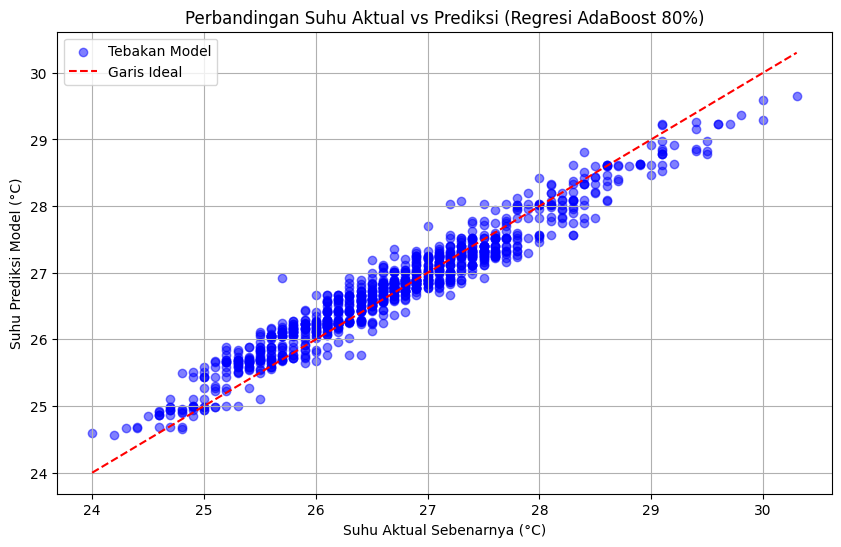

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predict_adaboost, alpha=0.5, color='blue', label='Tebakan Model')
min_val = min(y_test.min(), predict_adaboost.min())
max_val = max(y_test.max(), predict_adaboost.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Garis Ideal')
plt.title('Perbandingan Suhu Aktual vs Prediksi (Regresi AdaBoost 80%)')
plt.xlabel('Suhu Aktual Sebenarnya (°C)')
plt.ylabel('Suhu Prediksi Model (°C)')
plt.legend()
plt.grid(True)

plt.show()

In [52]:
#Regresi XGBoost
from xgboost import XGBRegressor
import time

time_start = time.perf_counter()
reg_xgboost = XGBRegressor()
reg_xgboost.fit(X_train,y_train)
end_time = time.perf_counter()

predict_xgboost = reg_xgboost.predict(X_test)

In [53]:
#Hasil Regresi XGBoost
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score as r2

mae_xgboost = mae(y_test, predict_xgboost)
rmse_xgboost = rmse(y_test,predict_xgboost)
mape_xgboost = mape(y_test,predict_xgboost)
r2_xgboost = r2(y_test,predict_xgboost)
duration_xgboost = end_time - time_start

print('MAE Model Regresi XGboost: {}'.format(mae_xgboost))
print('RMSE Model Regresi XGboost: {}'.format(rmse_xgboost))
print('MAPE Model Regresi XGboost: {}'.format(mape_xgboost))
print('R2 Model Regresi XGboost: {}'.format(r2_xgboost))
print('Waktu Pelatihan: {:.6f} Detik'.format(duration_xgboost))

MAE Model Regresi XGboost: 0.1402700063609179
RMSE Model Regresi XGboost: 0.18234047563062022
MAPE Model Regresi XGboost: 0.005233000178035907
R2 Model Regresi XGboost: 0.9649001555422163
Waktu Pelatihan: 0.057394 Detik


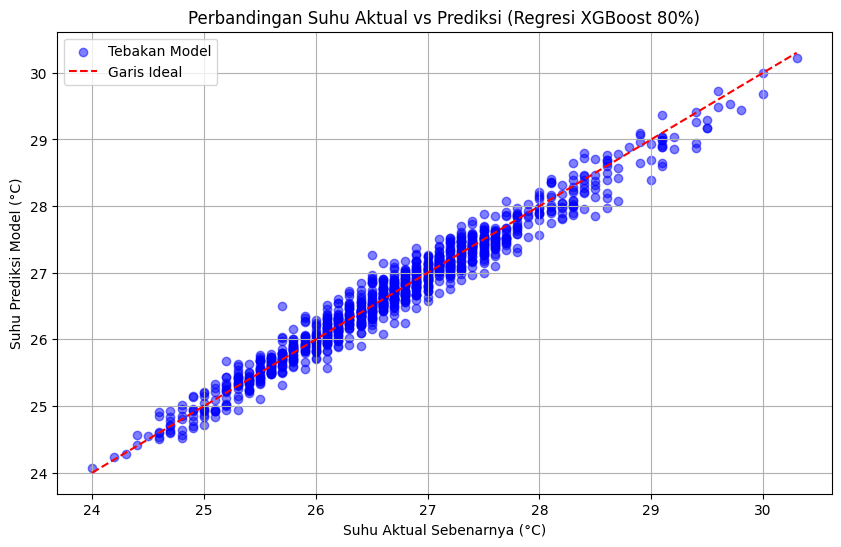

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predict_xgboost, alpha=0.5, color='blue', label='Tebakan Model')
min_val = min(y_test.min(), predict_xgboost.min())
max_val = max(y_test.max(), predict_xgboost.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Garis Ideal')
plt.title('Perbandingan Suhu Aktual vs Prediksi (Regresi XGBoost 80%)')
plt.xlabel('Suhu Aktual Sebenarnya (°C)')
plt.ylabel('Suhu Prediksi Model (°C)')
plt.legend()
plt.grid(True)

plt.show()

In [55]:
#Regresi CatBoost
from catboost import CatBoostRegressor
import time

time_start = time.perf_counter()
reg_catboost = CatBoostRegressor()
reg_catboost.fit(X_train,y_train)
end_time = time.perf_counter()

predict_catboost = reg_catboost.predict(X_test)

Learning rate set to 0.05224
0:	learn: 0.9506012	total: 1.51ms	remaining: 1.51s
1:	learn: 0.9103052	total: 3.02ms	remaining: 1.5s
2:	learn: 0.8711045	total: 4.21ms	remaining: 1.4s
3:	learn: 0.8352651	total: 5.34ms	remaining: 1.33s
4:	learn: 0.8010344	total: 6.52ms	remaining: 1.3s
5:	learn: 0.7693300	total: 7.72ms	remaining: 1.28s
6:	learn: 0.7381114	total: 9.17ms	remaining: 1.3s
7:	learn: 0.7090460	total: 10.5ms	remaining: 1.3s
8:	learn: 0.6811173	total: 11.6ms	remaining: 1.28s
9:	learn: 0.6542473	total: 12.8ms	remaining: 1.27s
10:	learn: 0.6282971	total: 14ms	remaining: 1.26s
11:	learn: 0.6046002	total: 15.1ms	remaining: 1.25s
12:	learn: 0.5823816	total: 16.2ms	remaining: 1.23s
13:	learn: 0.5607078	total: 17.3ms	remaining: 1.22s
14:	learn: 0.5399715	total: 18.5ms	remaining: 1.21s
15:	learn: 0.5213584	total: 19.6ms	remaining: 1.21s
16:	learn: 0.5026102	total: 20.7ms	remaining: 1.2s
17:	learn: 0.4851408	total: 21.8ms	remaining: 1.19s
18:	learn: 0.4689687	total: 22.9ms	remaining: 1.18s
1

In [56]:
#Hasil Regresi catboost
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score as r2

mae_catboost = mae(y_test, predict_catboost)
rmse_catboost = rmse(y_test,predict_catboost)
mape_catboost = mape(y_test,predict_catboost)
r2_catboost = r2(y_test,predict_catboost)
duration_catboost = end_time - time_start

print('MAE Model Regresi CatBoost: {}'.format(mae_catboost))
print('RMSE Model Regresi CatBoost: {}'.format(rmse_catboost))
print('MAPE Model Regresi CatBoost: {}'.format(mape_catboost))
print('R2 Model Regresi CatBoost: {}'.format(r2_catboost))
print('Waktu Pelatihan: {:.6f} Detik'.format(duration_catboost))

MAE Model Regresi CatBoost: 0.12659813865552416
RMSE Model Regresi CatBoost: 0.16456182229344996
MAPE Model Regresi CatBoost: 0.004724480594772205
R2 Model Regresi CatBoost: 0.9714111160893042
Waktu Pelatihan: 1.280025 Detik


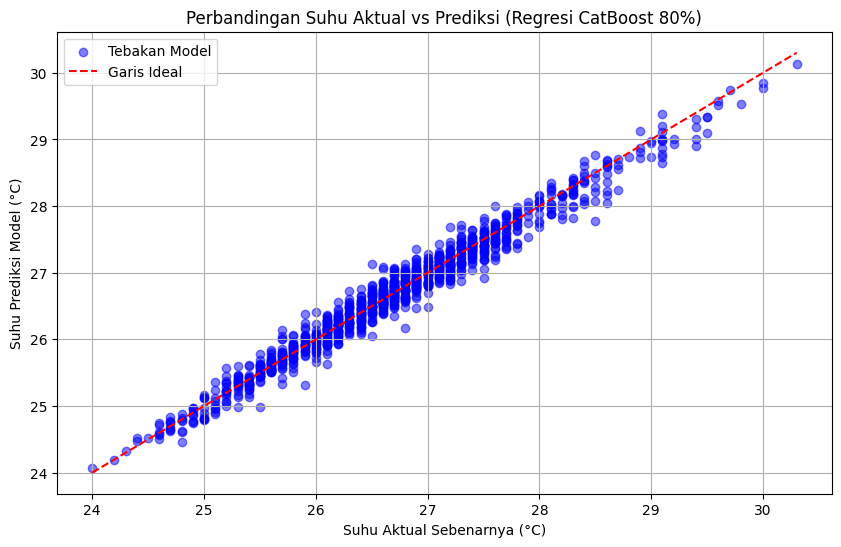

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predict_catboost, alpha=0.5, color='blue', label='Tebakan Model')
min_val = min(y_test.min(), predict_catboost.min())
max_val = max(y_test.max(), predict_catboost.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Garis Ideal')
plt.title('Perbandingan Suhu Aktual vs Prediksi (Regresi CatBoost 80%)')
plt.xlabel('Suhu Aktual Sebenarnya (°C)')
plt.ylabel('Suhu Prediksi Model (°C)')
plt.legend()
plt.grid(True)

plt.show()

In [58]:
#Regresi Light GBM
from lightgbm import LGBMRegressor
import time

time_start = time.perf_counter()
reg_lightgbm = LGBMRegressor()
reg_lightgbm.fit(X_train,y_train)
end_time = time.perf_counter()

predict_lightgbm = reg_lightgbm.predict(X_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000127 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1225
[LightGBM] [Info] Number of data points in the train set: 4675, number of used features: 8
[LightGBM] [Info] Start training from score 26.664813


In [59]:
#Hasil Regresi lightgbm
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score as r2

mae_lightgbm = mae(y_test, predict_lightgbm)
rmse_lightgbm = rmse(y_test,predict_lightgbm)
mape_lightgbm = mape(y_test,predict_lightgbm)
r2_lightgbm = r2(y_test,predict_lightgbm)
duration_lightgbm = end_time - time_start

print('MAE Model Regresi lightgbm: {}'.format(mae_lightgbm))
print('RMSE Model Regresi lightgbm: {}'.format(rmse_lightgbm))
print('MAPE Model Regresi lightgbm: {}'.format(mape_lightgbm))
print('R2 Model Regresi lightgbm: {}'.format(r2_lightgbm))
print('Waktu Pelatihan: {:.6f} Detik'.format(duration_lightgbm))

MAE Model Regresi lightgbm: 0.13456598835624373
RMSE Model Regresi lightgbm: 0.17398564361922977
MAPE Model Regresi lightgbm: 0.005018713743123729
R2 Model Regresi lightgbm: 0.9680430109810275
Waktu Pelatihan: 0.062688 Detik


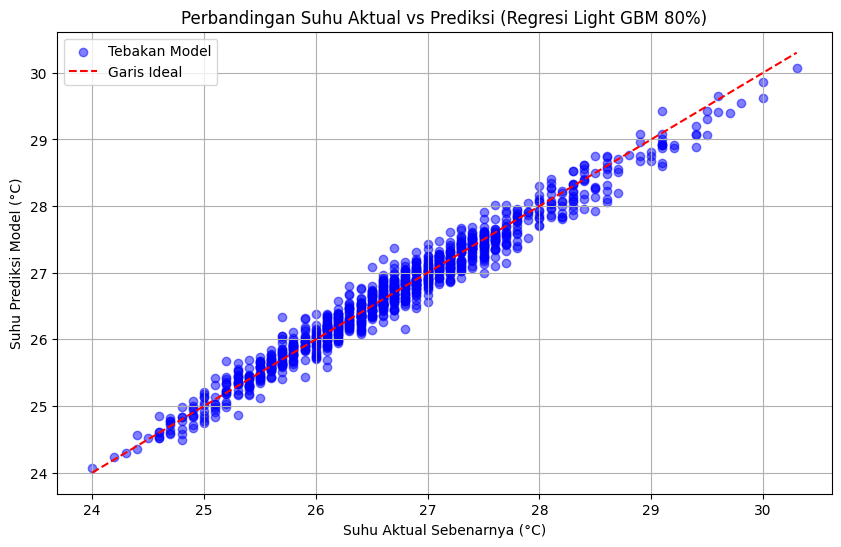

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predict_lightgbm, alpha=0.5, color='blue', label='Tebakan Model')
min_val = min(y_test.min(), predict_lightgbm.min())
max_val = max(y_test.max(), predict_lightgbm.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Garis Ideal')
plt.title('Perbandingan Suhu Aktual vs Prediksi (Regresi Light GBM 80%)')
plt.xlabel('Suhu Aktual Sebenarnya (°C)')
plt.ylabel('Suhu Prediksi Model (°C)')
plt.legend()
plt.grid(True)

plt.show()

In [61]:
#Regresi SVR Linear
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
import time

time_start = time.perf_counter()
reg_svl_linear = make_pipeline(StandardScaler(), SVR(kernel='linear',C=1.0, epsilon=0.2))
reg_svl_linear.fit(X_train,y_train)
end_time = time.perf_counter()

predict_svl_linear = reg_svl_linear.predict(X_test)

In [62]:
#Hasil Regresi SVR Linear
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score as r2

mae_svl_linear = mae(y_test, predict_svl_linear)
rmse_svl_linear = rmse(y_test,predict_svl_linear)
mape_svl_linear = mape(y_test,predict_svl_linear)
r2_svl_linear = r2(y_test,predict_svl_linear)
duration_svl_linear = end_time - time_start

print('MAE Model Regresi svl linear: {}'.format(mae_svl_linear))
print('RMSE Model Regresi svl linear: {}'.format(rmse_svl_linear))
print('MAPE Model Regresi svl linear: {}'.format(mape_svl_linear))
print('R2 Model Regresi svl linear: {}'.format(r2_svl_linear))
print('Waktu Pelatihan: {:.6f} Detik'.format(duration_svl_linear))

MAE Model Regresi svl linear: 0.1680414633411251
RMSE Model Regresi svl linear: 0.21296310212700634
MAPE Model Regresi svl linear: 0.0062794564609694485
R2 Model Regresi svl linear: 0.9521207042327829
Waktu Pelatihan: 0.613347 Detik


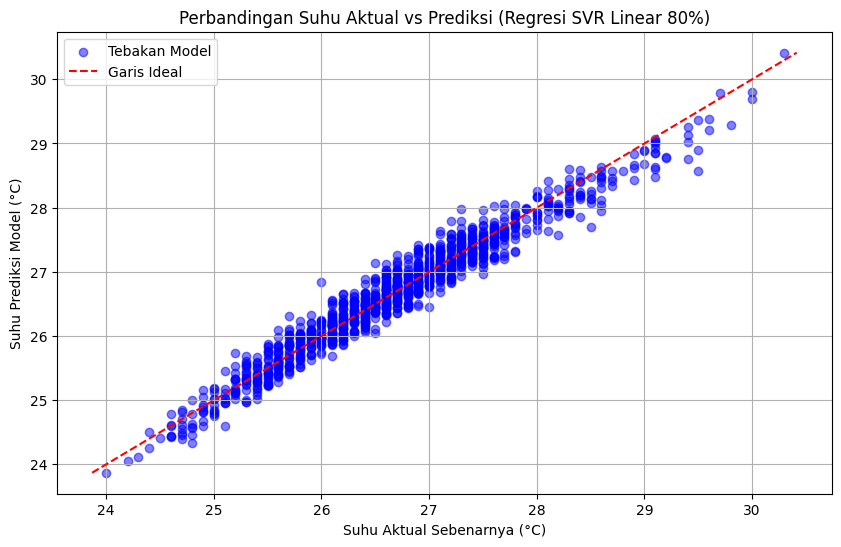

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predict_svl_linear, alpha=0.5, color='blue', label='Tebakan Model')
min_val = min(y_test.min(), predict_svl_linear.min())
max_val = max(y_test.max(), predict_svl_linear.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Garis Ideal')
plt.title('Perbandingan Suhu Aktual vs Prediksi (Regresi SVR Linear 80%)')
plt.xlabel('Suhu Aktual Sebenarnya (°C)')
plt.ylabel('Suhu Prediksi Model (°C)')
plt.legend()
plt.grid(True)

plt.show()

In [64]:
#Regresi SVR RBF
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
import time

time_start = time.perf_counter()
reg_svl_rbf = make_pipeline(StandardScaler(), SVR(kernel='rbf',C=1.0, epsilon=0.2))
reg_svl_rbf.fit(X_train,y_train)
end_time = time.perf_counter()

predict_svl_rbf = reg_svl_rbf.predict(X_test)

In [65]:
#Hasil Regresi SVR RBF
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score as r2

mae_svl_rbf = mae(y_test, predict_svl_rbf)
rmse_svl_rbf = rmse(y_test,predict_svl_rbf)
mape_svl_rbf = mape(y_test,predict_svl_rbf)
r2_svl_rbf = r2(y_test,predict_svl_rbf)
duration_svl_rbf = end_time - time_start

print('MAE Model Regresi svl rbf: {}'.format(mae_svl_rbf))
print('RMSE Model Regresi svl rbf: {}'.format(rmse_svl_rbf))
print('MAPE Model Regresi svl rbf: {}'.format(mape_svl_rbf))
print('R2 Model Regresi svl rbf: {}'.format(r2_svl_rbf))
print('Waktu Pelatihan: {:.6f} Detik'.format(duration_svl_rbf))

MAE Model Regresi svl rbf: 0.12878395887589758
RMSE Model Regresi svl rbf: 0.16740545214793406
MAPE Model Regresi svl rbf: 0.00480360438373332
R2 Model Regresi svl rbf: 0.9704145471131047
Waktu Pelatihan: 0.145728 Detik


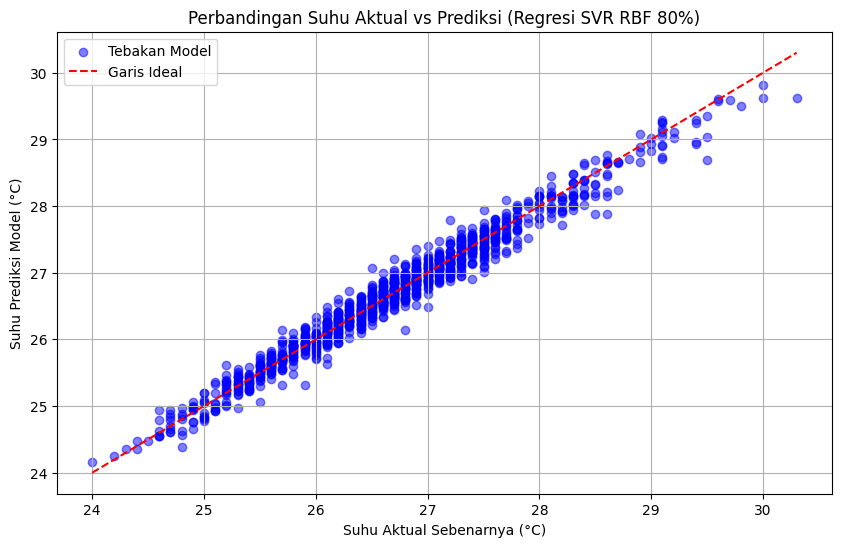

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predict_svl_rbf, alpha=0.5, color='blue', label='Tebakan Model')
min_val = min(y_test.min(), predict_svl_rbf.min())
max_val = max(y_test.max(), predict_svl_rbf.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Garis Ideal')
plt.title('Perbandingan Suhu Aktual vs Prediksi (Regresi SVR RBF 80%)')
plt.xlabel('Suhu Aktual Sebenarnya (°C)')
plt.ylabel('Suhu Prediksi Model (°C)')
plt.legend()
plt.grid(True)

plt.show()

In [67]:
#Regresi SVR Polynomial
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
import time

time_start = time.perf_counter()
reg_svl_poly = make_pipeline(StandardScaler(), SVR(kernel='poly',C=1.0, epsilon=0.2))
reg_svl_poly.fit(X_train,y_train)
end_time = time.perf_counter()

predict_svl_poly = reg_svl_poly.predict(X_test)

In [68]:
#Hasil Regresi SVR Polynomial
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score as r2

mae_svl_poly = mae(y_test, predict_svl_poly)
rmse_svl_poly = rmse(y_test,predict_svl_poly)
mape_svl_poly = mape(y_test,predict_svl_poly)
r2_svl_poly = r2(y_test,predict_svl_poly)
duration_svl_poly = end_time - time_start

print('MAE Model Regresi svl Polynomial: {}'.format(mae_svl_poly))
print('RMSE Model Regresi svl Polynomial: {}'.format(rmse_svl_poly))
print('MAPE Model Regresi svl Polynomial: {}'.format(mape_svl_poly))
print('R2 Model Regresi svl Polynomial: {}'.format(r2_svl_poly))
print('Waktu Pelatihan: {:.6f} Detik'.format(duration_svl_poly))

MAE Model Regresi svl Polynomial: 0.2998536702349727
RMSE Model Regresi svl Polynomial: 0.400025399879642
MAPE Model Regresi svl Polynomial: 0.01125107664893086
R2 Model Regresi svl Polynomial: 0.8310671296122498
Waktu Pelatihan: 0.745253 Detik


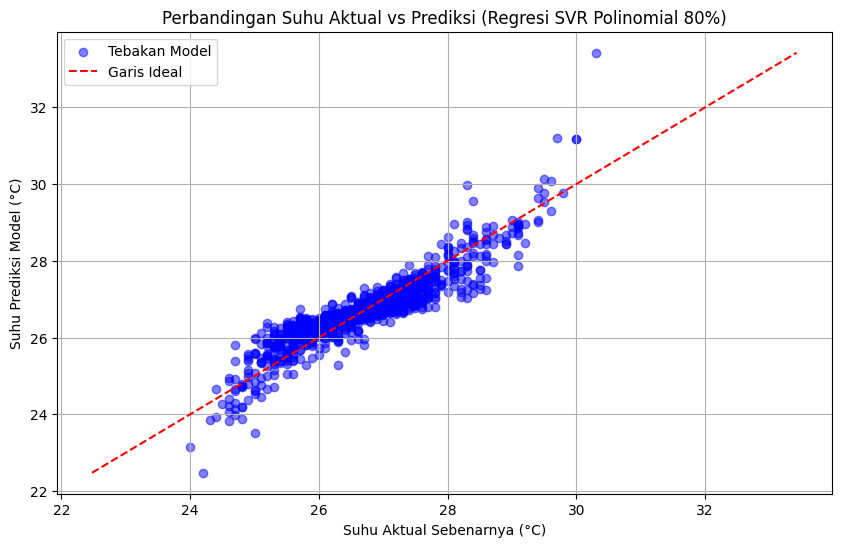

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predict_svl_poly, alpha=0.5, color='blue', label='Tebakan Model')
min_val = min(y_test.min(), predict_svl_poly.min())
max_val = max(y_test.max(), predict_svl_poly.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Garis Ideal')
plt.title('Perbandingan Suhu Aktual vs Prediksi (Regresi SVR Polinomial 80%)')
plt.xlabel('Suhu Aktual Sebenarnya (°C)')
plt.ylabel('Suhu Prediksi Model (°C)')
plt.legend()
plt.grid(True)

plt.show()